# VisionAI — Notebook d'expérimentation

Document interactif regroupant toutes nos expériences :
1. Validation sur les cas de test (XOR, AND, OR) + visualisation des frontières
2. Entraînement sur le dataset d'images + matrice de confusion
3. Courbe d'apprentissage (perte et exactitude)
4. Comparaison des 4 modèles (Linéaire, MLP, RBF, SVM)
5. Impact des hyperparamètres (activation)

**Prérequis :** binding construit (`cd python_binding && maturin develop --release`) et
fichiers `.npy` générés (`python preprocess_dataset.py`).


## 0. Imports et chargement du dataset

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import vision_ai

DATASET_DIR = "../datasets"
CLASSES = ["aucun", "humain", "animal"]

X_train = np.load(os.path.join(DATASET_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATASET_DIR, "y_train.npy")).astype(int)
X_test  = np.load(os.path.join(DATASET_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(DATASET_DIR, "y_test.npy")).astype(int)

INPUT_SIZE   = X_train.shape[1]
inputs_train = X_train.tolist()
inputs_test  = X_test.tolist()

def one_hot(labels, n=3):
    return [[1.0 if int(l) == k else 0.0 for k in range(n)] for l in labels]

targets_train = one_hot(y_train)

def classe(proba):
    return proba.index(max(proba))

def exactitude(predict_fn):
    y_pred = [classe(predict_fn(x)) for x in inputs_test]
    return accuracy_score(y_test, y_pred) * 100

print(f"Train : {X_train.shape[0]} images | Test : {X_test.shape[0]} images | {INPUT_SIZE} entrees")
for i, c in enumerate(CLASSES):
    print(f"  {c:8s} : {int(np.sum(y_train == i))} images train")

Train : 596 images | Test : 149 images | 12288 entrees
  aucun    : 198 images train
  humain   : 198 images train
  animal   : 200 images train


## 1. Validation sur les cas de test

On vérifie d'abord que nos modèles apprennent correctement sur des problèmes
dont on connaît la réponse (XOR, AND, OR). Le XOR n'est pas séparable
linéairement : s'il est appris, c'est que toute la chaîne fonctionne.


In [ ]:
XOR = ([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], [0,1,1,0])
AND = ([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], [0,0,0,1])
OR  = ([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], [0,1,1,1])

def run_cas(nom, data, fabrique, lr, epochs, tentatives=5):
    entrees, labels = data
    cibles = [[1.0 if l == k else 0.0 for k in range(2)] for l in labels]
    for t in range(1, tentatives + 1):
        m = fabrique()
        m.train(entrees, cibles, lr, epochs)
        pred = [classe(m.predict(x)) for x in entrees]
        ok = sum(p == l for p, l in zip(pred, labels))
        if ok == len(labels):
            print(f"{nom:22s} : REUSSI en {t} tentative(s)")
            for x, p, l in zip(entrees, pred, labels):
                print(f"    {x} -> predit {p} (attendu {l})")
            return
    print(f"{nom:22s} : NON converge apres {tentatives} tentatives")

run_cas("XOR (MLP)", XOR, lambda: vision_ai.PyMLP([2,1,2], "sigmoid"), 0.1, 1000000)
run_cas("AND (MLP)", AND, lambda: vision_ai.PyMLP([2,8,2], "sigmoid"), 0.5, 2000)
run_cas("OR  (MLP)", OR,  lambda: vision_ai.PyMLP([2,8,2], "sigmoid"), 0.5, 2000)
run_cas("XOR (SVM noyau RBF)", XOR, lambda: vision_ai.PySVM(c=5.0, kernel="rbf", gamma=1.0), 0.0, 200)

XOR (MLP)              : REUSSI en 1 tentative(s)
    [0.0, 0.0] -> predit 0 (attendu 0)
    [0.0, 1.0] -> predit 1 (attendu 1)
    [1.0, 0.0] -> predit 1 (attendu 1)
    [1.0, 1.0] -> predit 0 (attendu 0)
AND (MLP)              : REUSSI en 1 tentative(s)
    [0.0, 0.0] -> predit 0 (attendu 0)
    [0.0, 1.0] -> predit 0 (attendu 0)
    [1.0, 0.0] -> predit 0 (attendu 0)
    [1.0, 1.0] -> predit 1 (attendu 1)
OR  (MLP)              : REUSSI en 1 tentative(s)
    [0.0, 0.0] -> predit 0 (attendu 0)
    [0.0, 1.0] -> predit 1 (attendu 1)
    [1.0, 0.0] -> predit 1 (attendu 1)
    [1.0, 1.0] -> predit 1 (attendu 1)
XOR (SVM noyau RBF)    : REUSSI en 1 tentative(s)
    [0.0, 0.0] -> predit 0 (attendu 0)
    [0.0, 1.0] -> predit 1 (attendu 1)
    [1.0, 0.0] -> predit 1 (attendu 1)
    [1.0, 1.0] -> predit 0 (attendu 0)


### Visualisation : frontières de décision apprises

Pour chaque cas de test, on colore les zones de décision du modèle et on place
les 4 points (le chiffre = la classe prédite). Sur le XOR, la frontière n'est
pas une droite : le MLP sépare bien des données non linéairement séparables.


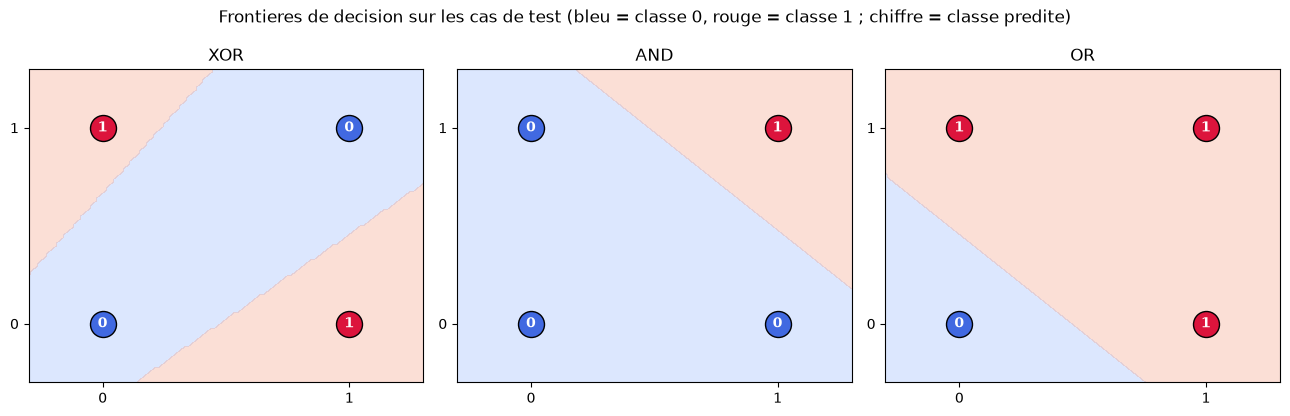

In [3]:
def frontiere_cas(ax, nom, data, fabrique, lr, epochs):
    entrees, labels = data
    cibles = [[1.0 if l == k else 0.0 for k in range(2)] for l in labels]
    m = fabrique()
    m.train(entrees, cibles, lr, epochs)
    xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 120), np.linspace(-0.3, 1.3, 120))
    Z = np.array([classe(m.predict([float(a), float(b)]))
                  for a, b in zip(xx.ravel(), yy.ravel())]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm", levels=1)
    for (x0, x1), l in zip(entrees, labels):
        p = classe(m.predict([x0, x1]))
        ax.scatter(x0, x1, c=("royalblue" if l == 0 else "crimson"), s=350, edgecolors="k", zorder=3)
        ax.annotate(str(p), (x0, x1), color="white", ha="center", va="center", fontweight="bold", zorder=4)
    ax.set_title(nom)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
frontiere_cas(axes[0], "XOR", XOR, lambda: vision_ai.PyMLP([2, 16, 2], "sigmoid"), 0.5, 3000)
frontiere_cas(axes[1], "AND", AND, lambda: vision_ai.PyMLP([2, 8, 2], "sigmoid"), 0.5, 2000)
frontiere_cas(axes[2], "OR",  OR,  lambda: vision_ai.PyMLP([2, 8, 2], "sigmoid"), 0.5, 2000)
fig.suptitle("Frontieres de decision sur les cas de test (bleu = classe 0, rouge = classe 1 ; chiffre = classe predite)")
fig.tight_layout()
plt.show()

## 2. Entraînement sur le dataset + matrice de confusion

On entraîne un MLP sur les images, puis on l'évalue sur le paquet test
(des images jamais vues). La matrice de confusion montre quelles classes
sont confondues.


Exactitude test : 61.1%  (hasard = 33%)


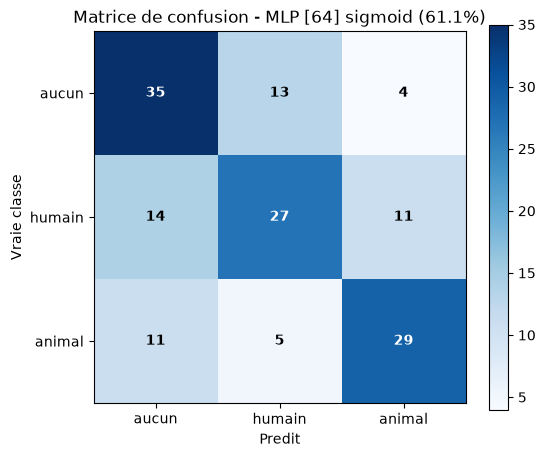

In [4]:
NEURONES, ACTIVATION, LR, EPOCHS = 64, "sigmoid", 0.005, 150

mlp = vision_ai.PyMLP([INPUT_SIZE, NEURONES, 3], ACTIVATION)
mlp.train(inputs_train, targets_train, LR, EPOCHS)

y_pred = [classe(mlp.predict(x)) for x in inputs_test]
acc = accuracy_score(y_test, y_pred) * 100
cm = confusion_matrix(y_test, y_pred)
print(f"Exactitude test : {acc:.1f}%  (hasard = 33%)")

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predit"); ax.set_ylabel("Vraie classe")
ax.set_title(f"Matrice de confusion - MLP [{NEURONES}] {ACTIVATION} ({acc:.1f}%)")
for i in range(3):
    for j in range(3):
        col = "white" if cm[i,j] > cm.max()/2 else "black"
        ax.text(j, i, cm[i,j], ha="center", va="center", color=col, fontweight="bold")
fig.colorbar(im); plt.show()

## 3. Courbe d'apprentissage

On entraîne par paliers pour tracer l'évolution de la perte (entraînement)
et de l'exactitude (test). Cela met en évidence le **sur-apprentissage** :
la perte continue de baisser alors que l'exactitude test stagne.


epoque   10 | perte 0.695 | test 49.0%
epoque   20 | perte 0.445 | test 52.3%
epoque   30 | perte 0.274 | test 53.0%
epoque   40 | perte 0.169 | test 55.0%
epoque   50 | perte 0.115 | test 55.7%
epoque   60 | perte 0.084 | test 53.7%
epoque   70 | perte 0.060 | test 53.7%
epoque   80 | perte 0.046 | test 54.4%
epoque   90 | perte 0.036 | test 54.4%
epoque  100 | perte 0.029 | test 55.7%
epoque  110 | perte 0.024 | test 55.7%
epoque  120 | perte 0.021 | test 57.0%
epoque  130 | perte 0.018 | test 57.0%
epoque  140 | perte 0.017 | test 57.0%
epoque  150 | perte 0.015 | test 57.0%


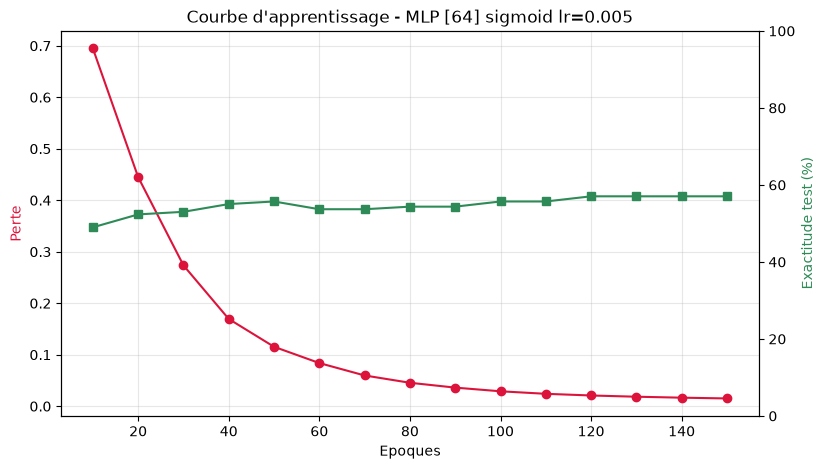

In [5]:
PAS, NB_PAS, LR = 10, 15, 0.005
NEURONES, ACTIVATION = 64, "sigmoid"

modele = vision_ai.PyMLP([INPUT_SIZE, NEURONES, 3], ACTIVATION)
epoques, pertes, accs = [], [], []
for k in range(NB_PAS):
    modele.train(inputs_train, targets_train, LR, PAS)
    perte = np.mean([-np.log(max(modele.predict(x)[t.index(1.0)], 1e-12))
                     for x, t in zip(inputs_train, targets_train)])
    accs.append(exactitude(modele.predict))
    pertes.append(perte); epoques.append((k+1)*PAS)
    print(f"epoque {epoques[-1]:4d} | perte {perte:.3f} | test {accs[-1]:.1f}%")

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(epoques, pertes, "o-", color="crimson"); ax1.set_xlabel("Epoques")
ax1.set_ylabel("Perte", color="crimson"); ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx(); ax2.plot(epoques, accs, "s-", color="seagreen")
ax2.set_ylabel("Exactitude test (%)", color="seagreen"); ax2.set_ylim(0, 100)
plt.title(f"Courbe d'apprentissage - MLP [{NEURONES}] {ACTIVATION} lr={LR}")
plt.show()

## 4. Comparaison des 4 modèles

On entraîne les quatre modèles imposés sur le dataset et on compare leur
exactitude. Cela justifie notre choix de modèle.


Lineaire  : 34.9%  (4.4s)
MLP       : 54.4%  (55.1s)
RBF       : 51.0%  (31.4s)
SVM       : 54.4%  (1.9s)


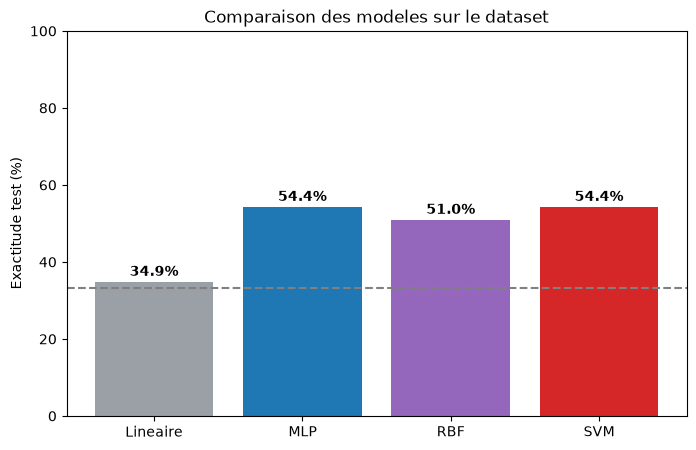

In [6]:
import time
resultats = {}

t0 = time.time()
lin = []
for k in range(3):
    yk = [[1.0 if int(l)==k else 0.0] for l in y_train]
    m = vision_ai.LinearRegression(INPUT_SIZE); m.train(inputs_train, yk, 200, 0.01); lin.append(m)
resultats["Lineaire"] = accuracy_score(y_test, [int(np.argmax([m.predict(x)[0] for m in lin])) for x in inputs_test]) * 100
print(f"Lineaire  : {resultats['Lineaire']:.1f}%  ({time.time()-t0:.1f}s)")

t0 = time.time()
mlp2 = vision_ai.PyMLP([INPUT_SIZE, 64, 3], "sigmoid"); mlp2.train(inputs_train, targets_train, 0.005, 60)
resultats["MLP"] = exactitude(mlp2.predict)
print(f"MLP       : {resultats['MLP']:.1f}%  ({time.time()-t0:.1f}s)")

t0 = time.time()
rbf = vision_ai.PyRBF(INPUT_SIZE, 3, 40, 35.0); rbf.train(inputs_train, targets_train, 0.05, 50)
resultats["RBF"] = exactitude(rbf.predict)
print(f"RBF       : {resultats['RBF']:.1f}%  ({time.time()-t0:.1f}s)")

t0 = time.time()
svm = vision_ai.PySVM(c=1.0, kernel="linear"); svm.train(inputs_train, targets_train, 0.001, 100)
resultats["SVM"] = exactitude(svm.predict)
print(f"SVM       : {resultats['SVM']:.1f}%  ({time.time()-t0:.1f}s)")

fig, ax = plt.subplots(figsize=(8,5))
b = ax.bar(list(resultats.keys()), list(resultats.values()),
           color=["#9aa0a6","#1f77b4","#9467bd","#d62728"])
ax.axhline(33.3, color="gray", ls="--"); ax.set_ylim(0,100); ax.set_ylabel("Exactitude test (%)")
ax.set_title("Comparaison des modeles sur le dataset")
for bar, v in zip(b, resultats.values()):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.show()

## 5. Impact des hyperparamètres : sigmoid vs tanh

À réglages égaux, on compare deux fonctions d'activation. Cela illustre
l'effet d'un hyperparamètre sur la dynamique d'apprentissage.


In [7]:
for act in ["sigmoid", "tanh"]:
    m = vision_ai.PyMLP([INPUT_SIZE, 64, 3], act)
    m.train(inputs_train, targets_train, 0.005, 100)
    print(f"activation {act:8s} -> exactitude test {exactitude(m.predict):.1f}%")

activation sigmoid  -> exactitude test 63.1%
activation tanh     -> exactitude test 49.7%
